# U.S. Flight Delays: Exploratory Data Analysis
### June 2026 On-Time Performance from Bureau of Transportation Statistics

**Author:** Ridhima  
**Tools:** Python · pandas · NumPy · matplotlib · seaborn  
**Data source:** [BTS TranStats](https://www.transtats.bts.gov/) Reporting Carrier On-Time Performance (Table 236), June 2026

## Project overview
This notebook explores one month of U.S. domestic flight records from the Bureau of Transportation
Statistics to answer the question: **what drives departure delays, and where could a traveler
or an airline focus to reduce them?**

BTS defines a flight as *on-time* if it departs or arrives fewer than 15 minutes after schedule which is the
threshold used throughout this analysis.

**Workflow**
1. Load & inspect the raw BTS extract
2. Assess data quality & clean (nulls, cancellations, types, text)
3. Engineer features (airline names, time-of-day, delay flags)
4. Explore delays across carriers, times, routes, and causes
5. Summarize findings & recommendations

## 1. Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

## 2. Load the data

In [38]:

CSV_PATH = "T_ONTIME_REPORTING.csv"

df = pd.read_csv(CSV_PATH)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 607,577  |  Columns: 29


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,CANCELLED,CANCELLATION_CODE,DIVERTED,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2026,6,1,1,6/1/2026 12:00:00 AM,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",725,719.0,-6.0,0.0,1035,1041.0,6.0,6.0,0.0,NaN,0.0,343.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2026,6,1,1,6/1/2026 12:00:00 AM,AA,10,LAX,"Los Angeles, CA",JFK,"New York, NY",2154,2152.0,-2.0,0.0,620,617.0,-3.0,0.0,0.0,NaN,0.0,306.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2026,6,1,1,6/1/2026 12:00:00 AM,AA,1002,MSN,"Madison, WI",CLT,"Charlotte, NC",700,649.0,-11.0,0.0,1018,959.0,-19.0,0.0,0.0,NaN,0.0,101.0,708.0,NaN,NaN,NaN,NaN,NaN
3,2026,6,1,1,6/1/2026 12:00:00 AM,AA,1004,ORD,"Chicago, IL",STL,"St. Louis, MO",2240,2239.0,-1.0,0.0,2354,2356.0,2.0,2.0,0.0,NaN,0.0,46.0,258.0,NaN,NaN,NaN,NaN,NaN
4,2026,6,1,1,6/1/2026 12:00:00 AM,AA,1007,CLT,"Charlotte, NC",PNS,"Pensacola, FL",2204,2203.0,-1.0,0.0,2242,2236.0,-6.0,0.0,0.0,NaN,0.0,73.0,488.0,NaN,NaN,NaN,NaN,NaN


## 3. First look
Inspect columns, types, and the scale of missingness.

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607577 entries, 0 to 607576
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 607577 non-null  int64  
 1   MONTH                607577 non-null  int64  
 2   DAY_OF_MONTH         607577 non-null  int64  
 3   DAY_OF_WEEK          607577 non-null  int64  
 4   FL_DATE              607577 non-null  str    
 5   OP_UNIQUE_CARRIER    607577 non-null  str    
 6   OP_CARRIER_FL_NUM    607577 non-null  int64  
 7   ORIGIN               607577 non-null  str    
 8   ORIGIN_CITY_NAME     607577 non-null  str    
 9   DEST                 607577 non-null  str    
 10  DEST_CITY_NAME       607577 non-null  str    
 11  CRS_DEP_TIME         607577 non-null  int64  
 12  DEP_TIME             598062 non-null  float64
 13  DEP_DELAY            598023 non-null  float64
 14  DEP_DELAY_NEW        598023 non-null  float64
 15  CRS_ARR_TIME         607577 

In [40]:
# Focus on the columns this analysis uses
cols = ['FL_DATE','OP_UNIQUE_CARRIER','OP_CARRIER_FL_NUM','ORIGIN','DEST',
        'CRS_DEP_TIME','DEP_TIME','DEP_DELAY','DEP_DELAY_NEW',
        'ARR_DELAY','ARR_DELAY_NEW','CANCELLED','CANCELLATION_CODE','DIVERTED',
        'AIR_TIME','DISTANCE','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY',
        'SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
df = df[[c for c in cols if c in df.columns]].copy()
df.describe(include='all').T[['count','mean','min','max']]

,count,mean,min,max
FL_DATE,607577,NaN,NaN,NaN
OP_UNIQUE_CARRIER,607577,NaN,NaN,NaN
OP_CARRIER_FL_NUM,607577.0,2601.149056,1.0,8796.0
ORIGIN,607577,NaN,NaN,NaN
DEST,607577,NaN,NaN,NaN
CRS_DEP_TIME,607577.0,1331.807935,1.0,2359.0
DEP_TIME,598062.0,1334.846273,1.0,2400.0
DEP_DELAY,598023.0,17.624033,-34.0,2759.0
DEP_DELAY_NEW,598023.0,20.657172,0.0,2759.0
ARR_DELAY,595195.0,11.681422,-73.0,2752.0


## 4. Data quality assessment

In [41]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
quality[quality['missing'] > 0].sort_values('missing', ascending=False)

,missing,missing_%
CANCELLATION_CODE,597558,98.4
CARRIER_DELAY,454540,74.8
WEATHER_DELAY,454540,74.8
NAS_DELAY,454540,74.8
SECURITY_DELAY,454540,74.8
LATE_AIRCRAFT_DELAY,454540,74.8
ARR_DELAY,12382,2.0
ARR_DELAY_NEW,12382,2.0
AIR_TIME,12382,2.0
DEP_DELAY,9554,1.6


In [42]:
n_cancelled = int(df['CANCELLED'].sum())
n_diverted  = int(df['DIVERTED'].sum())
print(f"Cancelled flights: {n_cancelled:,} ({n_cancelled/len(df):.1%})")
print(f"Diverted flights:  {n_diverted:,} ({n_diverted/len(df):.1%})")
print(f"Unique carriers:   {df['OP_UNIQUE_CARRIER'].nunique()}")
print(f"Unique airports:   {df['ORIGIN'].nunique()} origins")

Cancelled flights: 10,019 (1.6%)
Diverted flights:  2,363 (0.4%)
Unique carriers:   12
Unique airports:   351 origins


**Notes on this real dataset**
- `DEP_DELAY` / `ARR_DELAY` are **null for cancelled flights** (they never departed) — expected, not an error.
- The five delay-cause columns (`CARRIER_DELAY`, `WEATHER_DELAY`, …) are **only populated when a flight is 15+ minutes late**; they're blank otherwise. We'll fill those with 0.
- `DEP_DELAY_NEW` is departure delay in minutes with early departures floored at 0; `DEP_DELAY` keeps negatives (early). We keep both.

## 5. Data cleaning

In [43]:
df_clean = df.copy()

# 5a. Separate cancelled flights — analyze delays on operated flights only
cancelled = df_clean[df_clean['CANCELLED'] == 1].copy()
df_clean = df_clean[df_clean['CANCELLED'] == 0].copy()
print(f"Operated flights retained: {len(df_clean):,}")

Operated flights retained: 597,558


In [44]:
# 5b. Delay-cause columns: blank => 0 (flight wasn't late enough to attribute a cause)
cause_cols = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
df_clean[cause_cols] = df_clean[cause_cols].fillna(0)

In [45]:
# 5c. Drop the small number of operated flights still missing core delay values
before = len(df_clean)
df_clean = df_clean.dropna(subset=['DEP_DELAY','ARR_DELAY'])
print(f"Dropped {before - len(df_clean)} operated flights with missing delay data")

Dropped 2363 operated flights with missing delay data


In [46]:
# 5d. Parse scheduled hour from HHMM integer (e.g. 725 -> 7, 2154 -> 21)
df_clean['dep_hour'] = (df_clean['CRS_DEP_TIME'] // 100).astype(int)
# BTS encodes midnight as 2400 occasionally -> map to 0
df_clean['dep_hour'] = df_clean['dep_hour'].replace(24, 0)
df_clean['FL_DATE'] = pd.to_datetime(df_clean['FL_DATE'])
df_clean[['CRS_DEP_TIME','dep_hour']].head()

/var/folders/sf/61p1v85x27v35t4qcj49f58m0000gn/T/ipykernel_14371/3255385060.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['FL_DATE'] = pd.to_datetime(df_clean['FL_DATE'])


,CRS_DEP_TIME,dep_hour
0,725,7
1,2154,21
2,700,7
3,2240,22
4,2204,22


## 6. Feature engineering

In [47]:
# 6a. Map carrier codes to airline names
carrier_names = {
    'AA':'American','DL':'Delta','UA':'United','WN':'Southwest','AS':'Alaska',
    'B6':'JetBlue','NK':'Spirit','F9':'Frontier','G4':'Allegiant','HA':'Hawaiian',
    'OO':'SkyWest','YX':'Republic','MQ':'Envoy','OH':'PSA','9E':'Endeavor',
    'YV':'Mesa','QX':'Horizon','C5':'CommuteAir','ZW':'Air Wisconsin'}
df_clean['airline'] = df_clean['OP_UNIQUE_CARRIER'].map(carrier_names).fillna(df_clean['OP_UNIQUE_CARRIER'])

# 6b. On-time flag (BTS standard: >15 min late)
df_clean['delayed'] = df_clean['DEP_DELAY'] > 15

# 6c. Time-of-day bucket
def part_of_day(h):
    if h < 12: return 'Morning'
    if h < 17: return 'Afternoon'
    return 'Evening'
df_clean['time_of_day'] = df_clean['dep_hour'].apply(part_of_day)

df_clean[['airline','dep_hour','time_of_day','DEP_DELAY','delayed']].head()

,airline,dep_hour,time_of_day,DEP_DELAY,delayed
0,American,7,Morning,-6.0,False
1,American,21,Evening,-2.0,False
2,American,7,Morning,-11.0,False
3,American,22,Evening,-1.0,False
4,American,22,Evening,-1.0,False


## 7. Exploratory analysis

### 7.1 Overall delay distribution

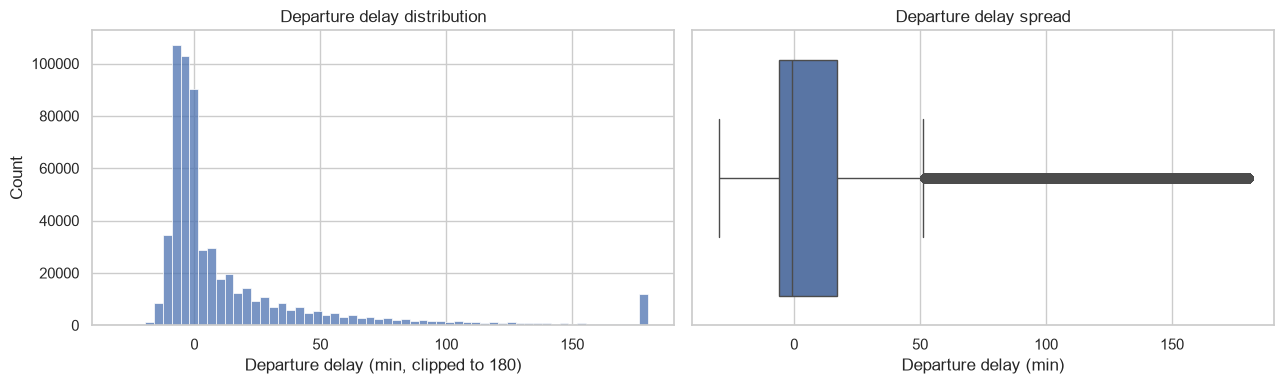

Median departure delay: -1 min
Mean departure delay:   17.5 min
Share delayed >15 min:  25.8%


In [48]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
# clip extreme tail for readability
sns.histplot(df_clean['DEP_DELAY'].clip(-30, 180), bins=60, ax=ax[0], color="#4C72B0")
ax[0].set_title("Departure delay distribution")
ax[0].set_xlabel("Departure delay (min, clipped to 180)")
sns.boxplot(x=df_clean['DEP_DELAY'].clip(-30, 180), ax=ax[1], color="#4C72B0")
ax[1].set_title("Departure delay spread")
ax[1].set_xlabel("Departure delay (min)")
plt.tight_layout(); plt.show()

print(f"Median departure delay: {df_clean['DEP_DELAY'].median():.0f} min")
print(f"Mean departure delay:   {df_clean['DEP_DELAY'].mean():.1f} min")
print(f"Share delayed >15 min:  {df_clean['delayed'].mean():.1%}")

### 7.2 On-time performance by airline

In [49]:
airline_stats = (df_clean.groupby('airline')
                 .agg(avg_delay=('DEP_DELAY','mean'),
                      pct_delayed=('delayed','mean'),
                      flights=('DEP_DELAY','size'))
                 .query('flights >= 500')          # focus on carriers with real volume
                 .sort_values('avg_delay', ascending=False))
airline_stats['avg_delay'] = airline_stats['avg_delay'].round(1)
airline_stats['pct_delayed'] = (airline_stats['pct_delayed']*100).round(1)
airline_stats

,avg_delay,pct_delayed,flights
airline,,,
American,27.1,31.3,83677
PSA,25.3,27.4,19346
Allegiant,25.0,28.1,12551
Southwest,21.3,38.4,119743
Frontier,20.8,27.7,18662
JetBlue,17.2,24.4,20399
United,16.1,21.9,72045
SkyWest,14.1,20.1,72322
Envoy,13.9,21.2,28100


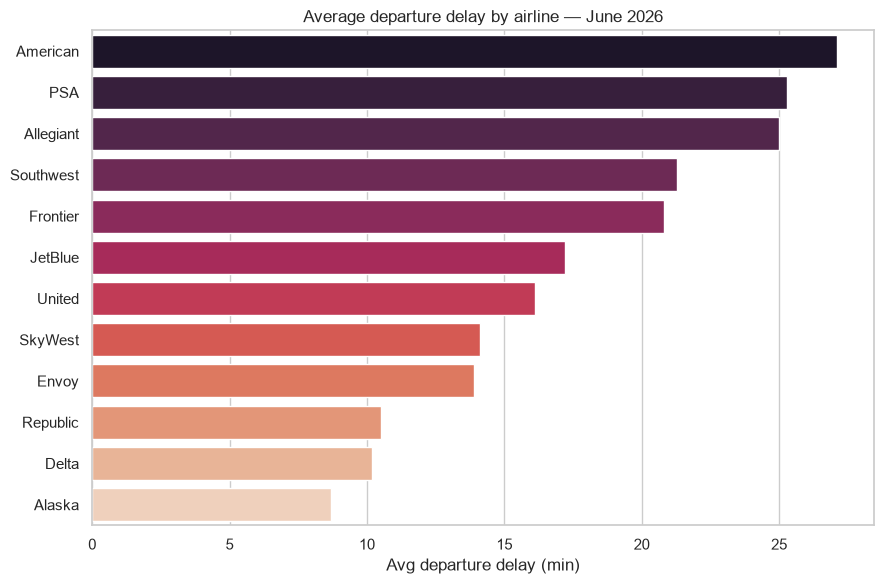

In [50]:
plt.figure(figsize=(9,6))
sns.barplot(data=airline_stats.reset_index(), x='avg_delay', y='airline',
            palette='rocket', hue='airline', legend=False)
plt.title("Average departure delay by airline — June 2026")
plt.xlabel("Avg departure delay (min)"); plt.ylabel("")
plt.tight_layout(); plt.show()

### 7.3 Delay by time of day

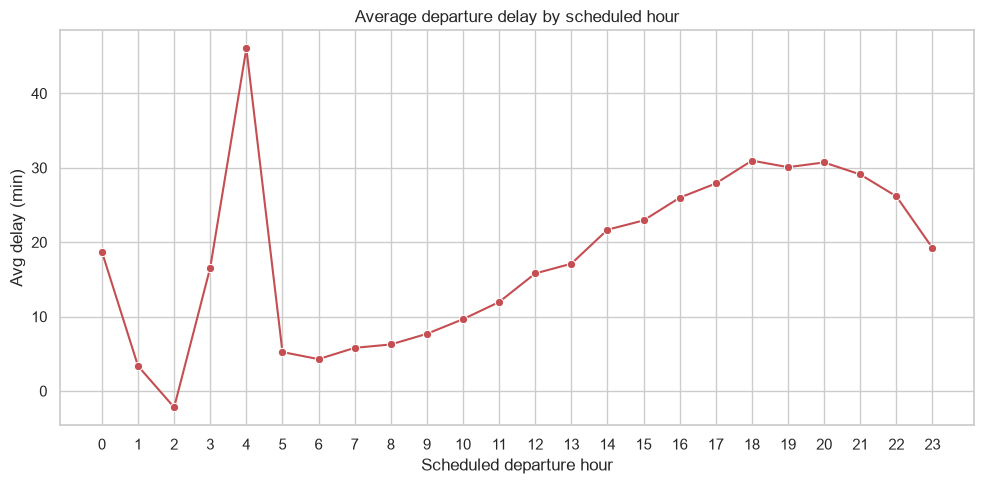

Average delay by time of day:
 time_of_day
Morning       7.3
Afternoon    20.6
Evening      29.1
Name: DEP_DELAY, dtype: float64


In [51]:
hourly = df_clean.groupby('dep_hour')['DEP_DELAY'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o', color="#C44E52")
plt.title("Average departure delay by scheduled hour")
plt.xlabel("Scheduled departure hour"); plt.ylabel("Avg delay (min)")
plt.xticks(range(0,24)); plt.tight_layout(); plt.show()

tod = (df_clean.groupby('time_of_day')['DEP_DELAY']
       .mean().reindex(['Morning','Afternoon','Evening']).dropna().round(1))
print("Average delay by time of day:\n", tod)

### 7.4 What causes delays? (BTS delay-cause breakdown)

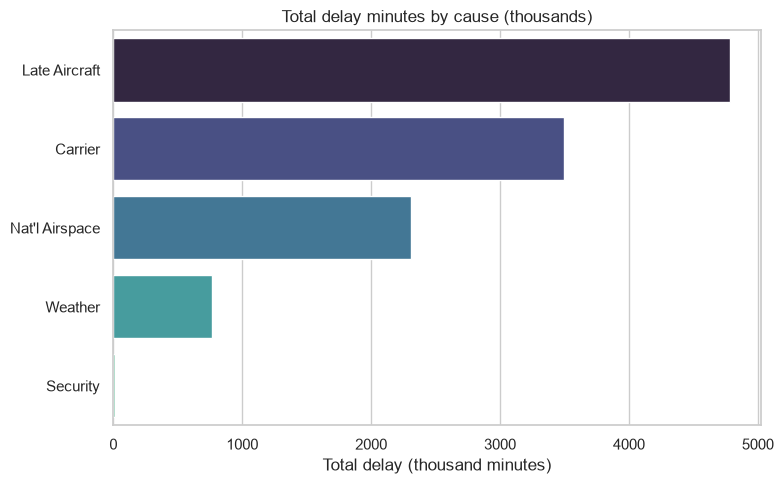

Share of total delay minutes by cause:
Late Aircraft     42.1%
Carrier           30.8%
Nat'l Airspace    20.3%
Weather            6.7%
Security           0.1%
dtype: str


In [52]:
# Sum each cause across all flights; these are the official BTS categories
cause_totals = df_clean[cause_cols].sum().sort_values(ascending=False)
cause_labels = {'CARRIER_DELAY':'Carrier','WEATHER_DELAY':'Weather','NAS_DELAY':'Nat\'l Airspace',
                'SECURITY_DELAY':'Security','LATE_AIRCRAFT_DELAY':'Late Aircraft'}
cause_totals.index = [cause_labels[c] for c in cause_totals.index]

plt.figure(figsize=(8,5))
sns.barplot(x=cause_totals.values/1e3, y=cause_totals.index, palette='mako',
            hue=cause_totals.index, legend=False)
plt.title("Total delay minutes by cause (thousands)")
plt.xlabel("Total delay (thousand minutes)"); plt.ylabel("")
plt.tight_layout(); plt.show()

print("Share of total delay minutes by cause:")
print((cause_totals / cause_totals.sum() * 100).round(1).astype(str) + '%')

### 7.5 Busiest routes and their reliability

In [53]:
df_clean['route'] = df_clean['ORIGIN'] + '→' + df_clean['DEST']
route_stats = (df_clean.groupby('route')
               .agg(flights=('DEP_DELAY','size'), avg_delay=('DEP_DELAY','mean'))
               .query('flights >= 200')
               .sort_values('flights', ascending=False)
               .head(15).round(1))
route_stats

,flights,avg_delay
route,,
SFO→LAX,1078,20.0
LAX→SFO,1075,22.9
LGA→ORD,909,30.6
ORD→LGA,905,21.8
JFK→LAX,811,19.7
LAX→JFK,804,22.5
HNL→OGG,759,4.7
OGG→HNL,757,2.4
ORD→BOS,731,24.6


### 7.6 Airline × time-of-day delay rate

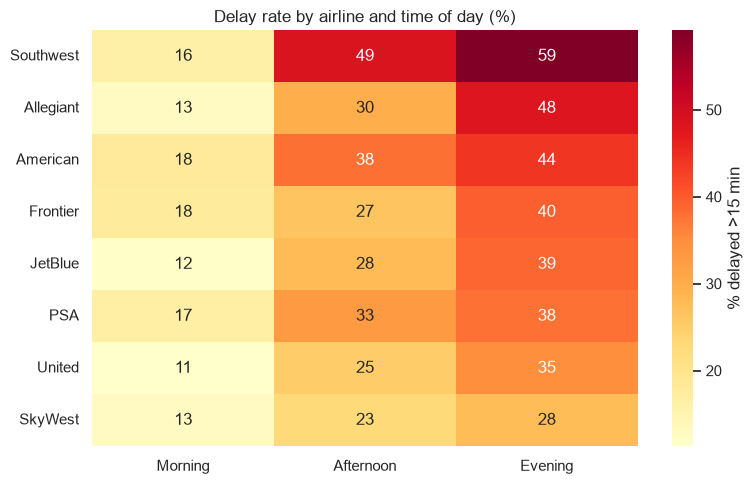

In [54]:
top_airlines = airline_stats.head(8).index
pivot = (df_clean[df_clean['airline'].isin(top_airlines)]
         .pivot_table(index='airline', columns='time_of_day',
                      values='delayed', aggfunc='mean'))
order = [c for c in ['Morning','Afternoon','Evening'] if c in pivot.columns]
pivot = pivot[order].sort_values(order[-1], ascending=False)
plt.figure(figsize=(8,5))
sns.heatmap(pivot*100, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label':'% delayed >15 min'})
plt.title("Delay rate by airline and time of day (%)")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout(); plt.show()

## 8. Key findings


1. **Delays are heavily right-skewed.** The median departure delay is about 1 minute but a long tail of longer delays pulls the mean above that. The histogram spikes near 0 and trails far to the right, so the median is a better representation of the data.

2. **On-time performance varies widely by airline.** Average departure delay ranged from the most reliable, Alaska with 8.5 minutes to the least reliable: American with rougly 27 minutes.

3. **Delays build through the day.** Morning departures are the most reliable with an average 7.3 minutes of delay with afternoon at 20.6 and evening 29.1. Evening flights are rougly 4 times the morning ones.

4. **Late aircraft and carrier-controllable issues are the top cause of delay** This shows that most delay is operational and not weather related. Late aircraft delay accounted for the most total delay minutes at 4.8 M followed by carrier delay at 3.5 M, weather was comparitively small and security was negligible.


## 9. Recommendations
- **Travelers:** book morning flights. They average 7.3 minutes of delay versus 29.1 in the evening, about 4x less. When price and schedule are close, pick a reliable airline like Alaska or Delta over American, PSA, or Allegiant.
- **Airline analysts:** focus on evening turnarounds. Late aircraft delay is the biggest cause (4.8M min) and delay rates climb through the day, so fixing delays earlier stops them cascading into the evening.
- **Focus on controllable causes:** late aircraft and carrier delays drive most of the total, far more than weather. Most delay this month was operational, so it's within the airlines control to fix.
- **Next steps:** compare multiple months for seasonality, add airport data for hub congestion, normalize for route mix, and model delay probability directly.

---
**Data:** U.S. DOT Bureau of Transportation Statistics, Reporting Carrier On-Time Performance, June 2026.  
**Methods:** pandas for cleaning/aggregation; matplotlib & seaborn for visualization. 